In [ ]:
# Numerical Computation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Performance Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Scikit-learn Perceptron (for comparison in Additional Task)
from sklearn.linear_model import Perceptron

In [ ]:
# Column names
column_names = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]

# Dataset URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"

# Load dataset
data = pd.read_csv(url, header=None, names=column_names)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
print("First Five Samples")
print(data.head())

First Five Samples
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


In [ ]:
print("\nDataset Shape")
print(data.shape)


Dataset Shape
(1372, 5)


In [ ]:
print("\nDataset Information")
data.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [ ]:
print("\nMissing Values")
print(data.isnull().sum())


Missing Values
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


In [ ]:
print("\nStatistical Summary")
print(data.describe())


Statistical Summary
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


In [ ]:
print("\nClass Distribution")
print(data["Class"].value_counts())


Class Distribution
Class
0    762
1    610
Name: count, dtype: int64


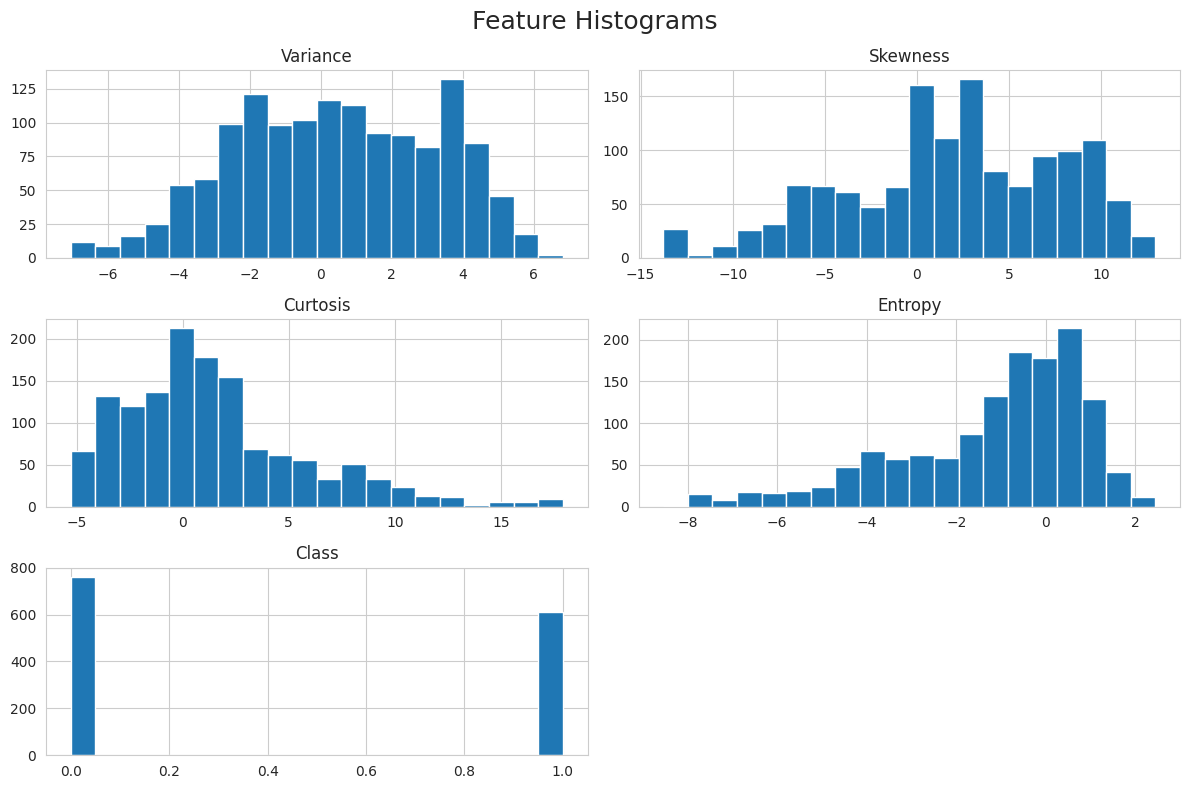

In [ ]:
data.hist(figsize=(12,8), bins=20)

plt.suptitle("Feature Histograms", fontsize=18)

plt.tight_layout()

plt.show()

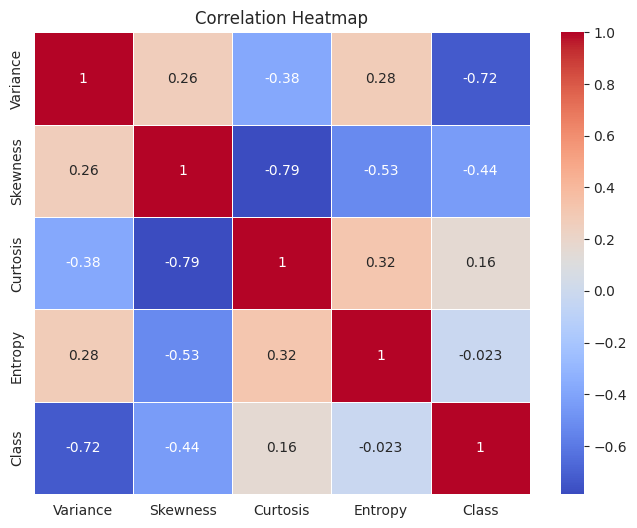

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

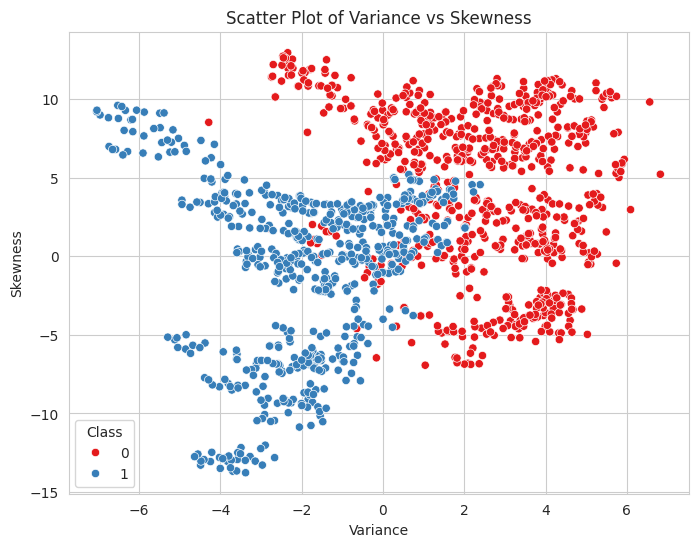

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Variance",
    y="Skewness",
    hue="Class",
    data=data,
    palette="Set1"
)

plt.title("Scatter Plot of Variance vs Skewness")

plt.show()

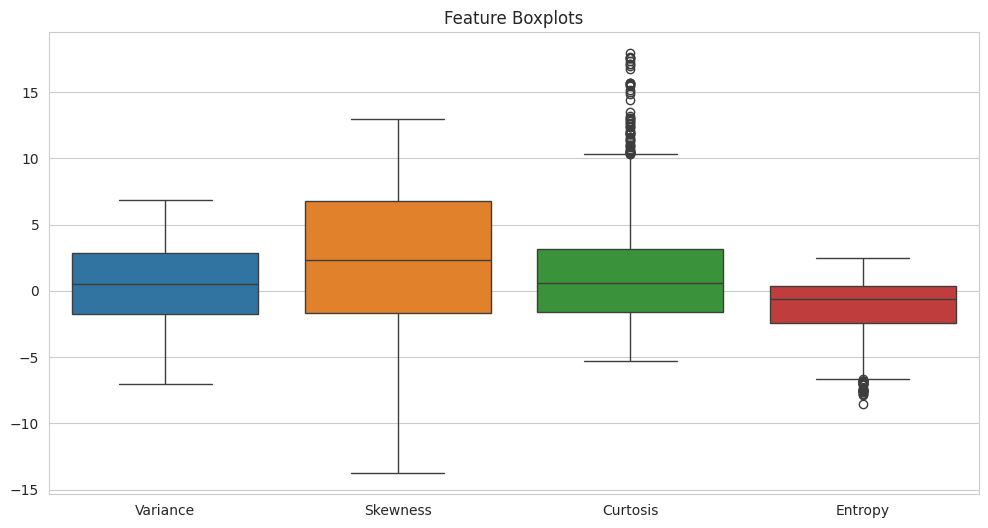

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=data.iloc[:,:4])

plt.title("Feature Boxplots")

plt.show()

In [ ]:
X = data.iloc[:,0:4].values
y = data.iloc[:,4].values

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

print("Features Normalized Successfully")

Features Normalized Successfully


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 1097
Testing Samples  : 275


In [ ]:
print("\nShape of Training Data")

print(X_train.shape)

print("\nShape of Testing Data")

print(X_test.shape)


Shape of Training Data
(1097, 4)

Shape of Testing Data
(275, 4)


In [ ]:
def step_function(z):
    """
    Step Activation Function
    """
    if z >= 0:
        return 1
    else:
        return 0

In [ ]:
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=20):

        # Hyperparameters
        self.lr = learning_rate
        self.epochs = epochs

        # Parameters
        self.weights = None
        self.bias = None

        # History for plotting
        self.error_history = []
        self.weight_history = []
        self.bias_history = []

    # Step Activation Function
    def step_function(self, z):

        if z >= 0:
            return 1
        else:
            return 0

    # Training Function
    def fit(self, X, y):

        # Number of input features
        n_features = X.shape[1]

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        print("Initial Weights :", self.weights)
        print("Initial Bias :", self.bias)

        # Training Loop
        for epoch in range(self.epochs):

            errors = 0

            print("\n====================================")
            print("Epoch :", epoch + 1)
            print("====================================")

            for i in range(len(X)):

                # Weighted Sum
                z = np.dot(X[i], self.weights) + self.bias

                # Prediction
                prediction = self.step_function(z)

                # Error
                error = y[i] - prediction

                if error != 0:

                    errors += 1

                    # Weight Update Rule
                    self.weights = self.weights + self.lr * error * X[i]

                    # Bias Update Rule
                    self.bias = self.bias + self.lr * error

                    print("\nSample :", i + 1)
                    print("Target :", y[i])
                    print("Prediction :", prediction)
                    print("Updated Weights :", self.weights)
                    print("Updated Bias :", self.bias)

            # Store history
            self.error_history.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print("\nMisclassified Samples :", errors)

            # Stop if converged
            if errors == 0:
                print("\nTraining Converged.")
                break

    # Prediction Function
    def predict(self, X):

        predictions = []

        for sample in X:

            z = np.dot(sample, self.weights) + self.bias

            prediction = self.step_function(z)

            predictions.append(prediction)

        return np.array(predictions)

In [ ]:
    def predict(self, X):

        predictions = []

        for sample in X:

            z = np.dot(sample, self.weights) + self.bias

            predictions.append(step_function(z))

        return np.array(predictions)

In [ ]:
model = Perceptron(
    learning_rate=0.01,
    epochs=20
)

In [ ]:
model.fit(X_train, y_train)

Initial Weights : [0. 0. 0. 0.]
Initial Bias : 0

Epoch : 1

Sample : 1
Target : 0
Prediction : 1
Updated Weights : [ 0.00641242 -0.01803377  0.00163967  0.03026807]
Updated Bias : -0.01

Sample : 4
Target : 0
Prediction : 1
Updated Weights : [-0.01091811 -0.02115867  0.00890939  0.01945717]
Updated Bias : -0.02

Sample : 6
Target : 1
Prediction : 0
Updated Weights : [-0.02555054 -0.02119046  0.00558326  0.01318246]
Updated Bias : -0.01

Sample : 19
Target : 0
Prediction : 1
Updated Weights : [-0.02874636 -0.0103765  -0.00994984  0.01576903]
Updated Bias : -0.02

Sample : 36
Target : 1
Prediction : 0
Updated Weights : [-0.03317939 -0.00860598 -0.01617951  0.01446898]
Updated Bias : -0.01

Sample : 63
Target : 1
Prediction : 0
Updated Weights : [-0.04964028 -0.03414883  0.02029287  0.00680301]
Updated Bias : 0.0

Sample : 70
Target : 0
Prediction : 1
Updated Weights : [-0.05496755 -0.0227354   0.00374548  0.0100176 ]
Updated Bias : -0.01

Sample : 75
Target : 1
Prediction : 0
Updated We

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9636363636363636


In [ ]:
precision = precision_score(y_test, y_pred)

print("Precision :", precision)

Precision : 1.0


In [ ]:
recall = recall_score(y_test, y_pred)

print("Recall :", recall)

Recall : 0.9212598425196851


In [ ]:
f1 = f1_score(y_test, y_pred)

print("F1 Score :", f1)

F1 Score : 0.9590163934426229


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[148   0]
 [ 10 117]]


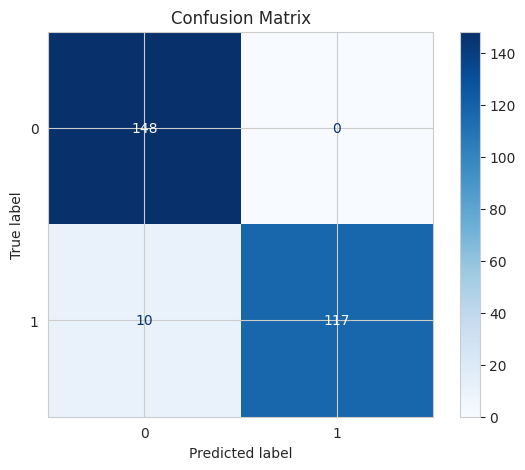

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

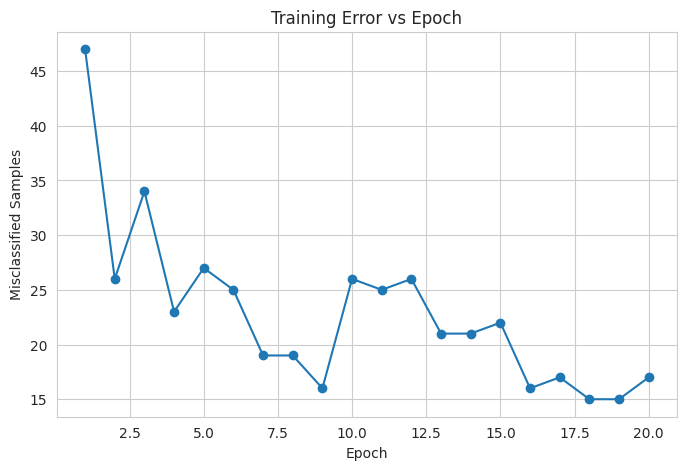

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(model.error_history)+1),
    model.error_history,
    marker='o'
)

plt.xlabel("Epoch")

plt.ylabel("Misclassified Samples")

plt.title("Training Error vs Epoch")

plt.grid(True)

plt.show()

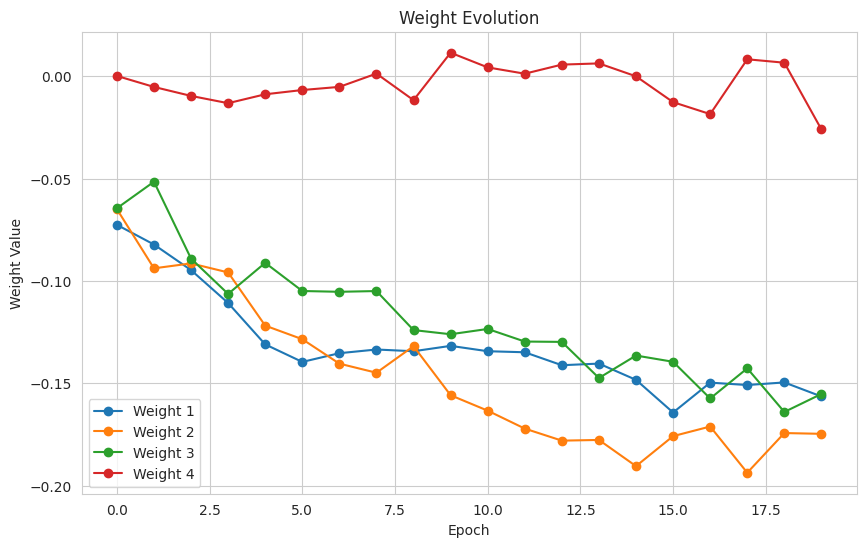

In [ ]:
weight_history = np.array(model.weight_history)

plt.figure(figsize=(10,6))

for i in range(weight_history.shape[1]):

    plt.plot(
        weight_history[:, i],
        marker='o',
        label=f"Weight {i+1}"
    )

plt.xlabel("Epoch")

plt.ylabel("Weight Value")

plt.title("Weight Evolution")

plt.legend()

plt.grid(True)

plt.show()

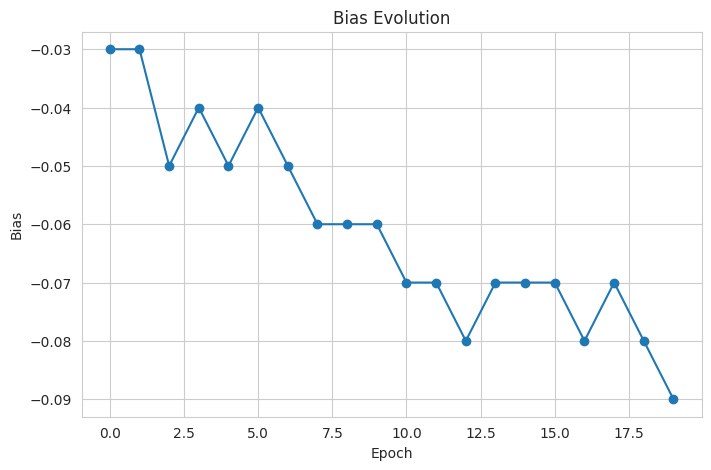

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    model.bias_history,
    marker='o'
)

plt.xlabel("Epoch")

plt.ylabel("Bias")

plt.title("Bias Evolution")

plt.grid(True)

plt.show()

In [ ]:
summary = pd.DataFrame({

    "Metric": [
        "Training Samples",
        "Testing Samples",
        "Learning Rate",
        "Epochs",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value": [

        len(X_train),

        len(X_test),

        model.lr,

        len(model.error_history),

        accuracy,

        precision,

        recall,

        f1
    ]

})

print(summary)

             Metric        Value
0  Training Samples  1097.000000
1   Testing Samples   275.000000
2     Learning Rate     0.010000
3            Epochs    20.000000
4          Accuracy     0.963636
5         Precision     1.000000
6            Recall     0.921260
7          F1 Score     0.959016


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,1])

In [ ]:
def step(x):
    if x >= 0:
        return 1
    return 0

In [ ]:
def plot_boundary(weights, bias, X, y, title):

    plt.figure(figsize=(6,6))

    colors = ['red' if i==0 else 'blue' for i in y]

    plt.scatter(
        X[:,0],
        X[:,1],
        c=colors,
        s=120
    )

    x_values = np.linspace(-0.5,1.5,100)

    if weights[1] != 0:

        y_values = -(weights[0]*x_values+bias)/weights[1]

        plt.plot(
            x_values,
            y_values,
            color='green'
        )

    plt.xlim(-0.5,1.5)
    plt.ylim(-0.5,1.5)

    plt.grid()

    plt.title(title)

    plt.xlabel("Input 1")
    plt.ylabel("Input 2")

    plt.show()

In [ ]:
learning_rate = 0.1

weights = np.zeros(2)

bias = 0

epoch = 0

print("Initial Weights :",weights)
print("Initial Bias :",bias)

Initial Weights : [0. 0.]
Initial Bias : 0



Epoch 1
----------------------------------
Sample : [0 0]
Target : 0
Prediction : 1
Updated Weights : [0. 0.]
Updated Bias : -0.1


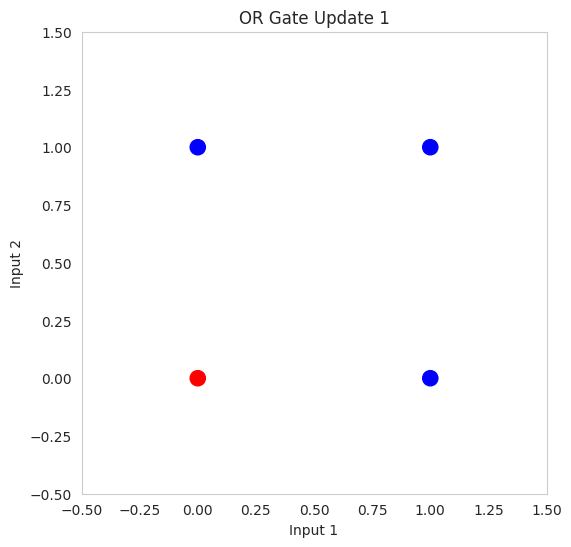

----------------------------------
Sample : [0 1]
Target : 1
Prediction : 0
Updated Weights : [0.  0.1]
Updated Bias : 0.0


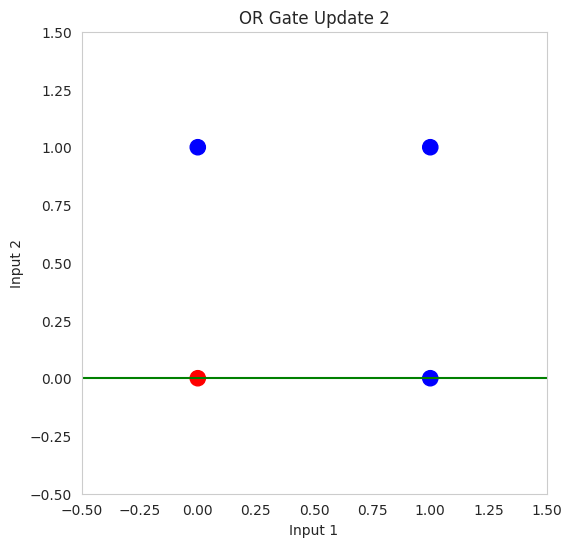


Epoch 2
----------------------------------
Sample : [0 0]
Target : 0
Prediction : 1
Updated Weights : [0.  0.1]
Updated Bias : -0.1


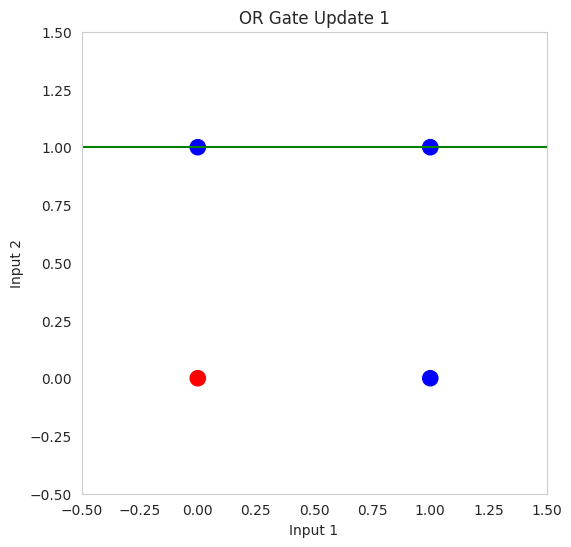

----------------------------------
Sample : [1 0]
Target : 1
Prediction : 0
Updated Weights : [0.1 0.1]
Updated Bias : 0.0


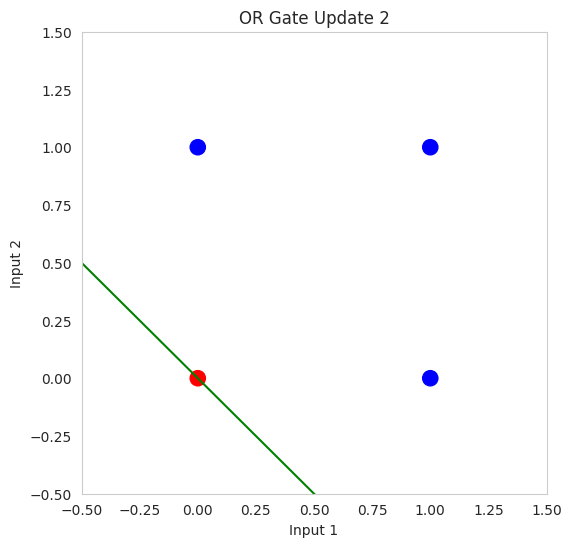


Epoch 3
----------------------------------
Sample : [0 0]
Target : 0
Prediction : 1
Updated Weights : [0.1 0.1]
Updated Bias : -0.1


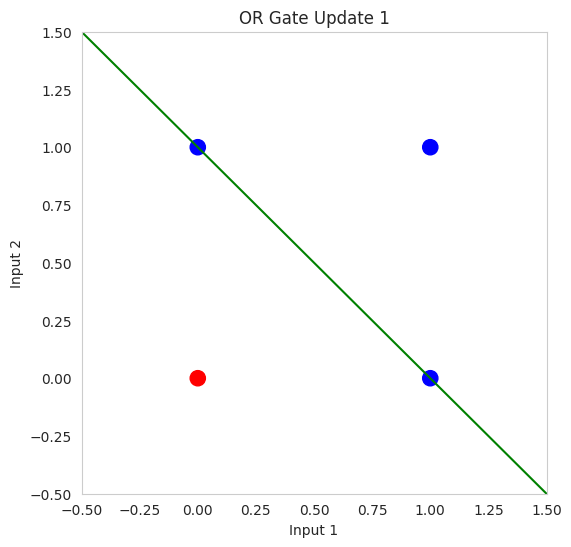


Epoch 4


In [ ]:
while True:

    errors = 0

    print("\nEpoch",epoch+1)

    for i in range(len(X)):

        z = np.dot(X[i],weights)+bias

        prediction = step(z)

        error = y[i]-prediction

        if error != 0:

            weights = weights + learning_rate*error*X[i]

            bias = bias + learning_rate*error

            errors += 1

            print("----------------------------------")
            print("Sample :",X[i])
            print("Target :",y[i])
            print("Prediction :",prediction)
            print("Updated Weights :",weights)
            print("Updated Bias :",bias)

            plot_boundary(
                weights,
                bias,
                X,
                y,
                f"OR Gate Update {errors}"
            )

    epoch += 1

    if errors == 0:
        break

In [ ]:
print("Training Completed")

print("Final Weights :",weights)

print("Final Bias :",bias)

Training Completed
Final Weights : [0.1 0.1]
Final Bias : -0.1


In [ ]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,0,0,1])

In [ ]:
X = np.array([
    [0],
    [1]
])

y = np.array([1,0])

In [ ]:
def plot_not(weights,bias):

    plt.figure(figsize=(6,2))

    plt.scatter(
        X,
        y,
        s=120
    )

    boundary = -bias/weights[0]

    plt.axvline(
        boundary,
        color='red'
    )

    plt.title("NOT Gate Decision Boundary")

    plt.grid()

    plt.show()


Epoch 1
Updated Weights : [-0.1]
Updated Bias : -0.1


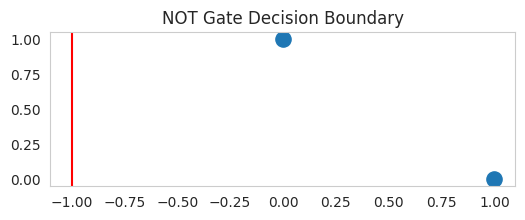


Epoch 2
Updated Weights : [-0.1]
Updated Bias : 0.0


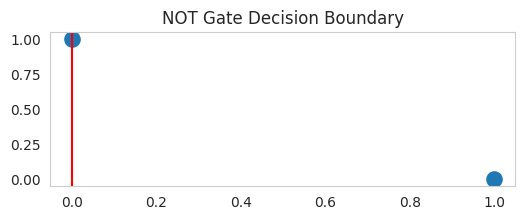


Epoch 3


In [ ]:
learning_rate = 0.1

weights = np.zeros(1)

bias = 0

epoch = 0

while True:

    errors = 0

    print("\nEpoch",epoch+1)

    for i in range(len(X)):

        z = np.dot(X[i],weights)+bias

        prediction = step(z)

        error = y[i]-prediction

        if error != 0:

            weights = weights + learning_rate*error*X[i]

            bias = bias + learning_rate*error

            print("Updated Weights :",weights)

            print("Updated Bias :",bias)

            plot_not(weights,bias)

            errors += 1

    epoch += 1

    if errors == 0:
        break

Learning Rate : 0.001
Accuracy : 0.9891
Learning Rate : 0.01
Accuracy : 0.9891
Learning Rate : 0.1
Accuracy : 0.9782

Learning Rate Comparison
   Learning Rate  Accuracy
0          0.001  0.989091
1          0.010  0.989091
2          0.100  0.978182


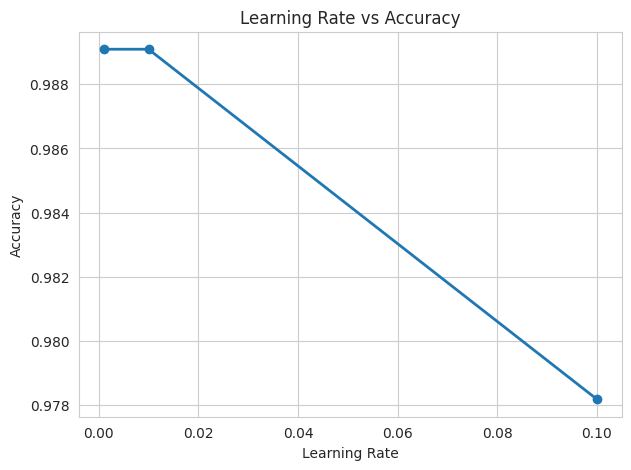

In [ ]:
# Additional Task 6
# Comparison of Different Learning Rates using Scikit-learn Perceptron

from sklearn.linear_model import Perceptron as SKPerceptron
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

learning_rates = [0.001, 0.01, 0.1]

accuracy_list = []

for lr in learning_rates:

    print("="*50)
    print("Learning Rate :", lr)

    # Scikit-learn Perceptron
    sk_model = SKPerceptron(
        eta0=lr,
        max_iter=1000,
        tol=1e-3,
        random_state=42
    )

    # Train
    sk_model.fit(X_train, y_train)

    # Predict
    y_pred = sk_model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    accuracy_list.append(accuracy)

    print("Accuracy :", round(accuracy,4))

# Display Results
results = pd.DataFrame({
    "Learning Rate": learning_rates,
    "Accuracy": accuracy_list
})

print("\nLearning Rate Comparison")
print(results)

# Plot
plt.figure(figsize=(7,5))
plt.plot(learning_rates, accuracy_list, marker='o', linewidth=2)
plt.title("Learning Rate vs Accuracy")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [ ]:
print("Dataset Size :", len(data))
print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))
print("Learning Rate :", model.lr)
print("Epochs :", len(model.error_history))
print("Final Weights :", model.weights)
print("Final Bias :", model.bias)
print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)

Dataset Size : 1372
Training Samples : 1097
Testing Samples : 275
Learning Rate : 0.01
Epochs : 20
Final Weights : [-0.15641765 -0.1746633  -0.15518554 -0.02596029]
Final Bias : -0.09
Accuracy : 0.9781818181818182
Precision : 1.0
Recall : 0.9212598425196851
F1-score : 0.9590163934426229


In [ ]:
weights = np.array(model.weight_history)

epoch_table = pd.DataFrame({
    "Epoch": range(1, len(model.error_history)+1),
    "Errors": model.error_history,
    "Weight 1": weights[:,0],
    "Weight 2": weights[:,1],
    "Weight 3": weights[:,2],
    "Weight 4": weights[:,3],
    "Bias": model.bias_history
})

print(epoch_table)

    Epoch  Errors  Weight 1  Weight 2  Weight 3  Weight 4  Bias
0       1      47 -0.072537 -0.064863 -0.064460  0.000199 -0.03
1       2      26 -0.082170 -0.093802 -0.051494 -0.005182 -0.03
2       3      34 -0.094676 -0.091400 -0.089055 -0.009565 -0.05
3       4      23 -0.110745 -0.095809 -0.106307 -0.013124 -0.04
4       5      27 -0.130964 -0.121796 -0.091128 -0.008771 -0.05
5       6      25 -0.139534 -0.128430 -0.104882 -0.006691 -0.04
6       7      19 -0.135270 -0.140369 -0.105269 -0.005157 -0.05
7       8      19 -0.133463 -0.144820 -0.104906  0.001333 -0.06
8       9      16 -0.134315 -0.131837 -0.123976 -0.011640 -0.06
9      10      26 -0.131687 -0.155810 -0.126006  0.011535 -0.06
10     11      25 -0.134304 -0.163344 -0.123422  0.004369 -0.07
11     12      26 -0.134814 -0.172105 -0.129577  0.001285 -0.07
12     13      21 -0.141143 -0.177991 -0.129746  0.005730 -0.08
13     14      21 -0.140347 -0.177649 -0.147387  0.006314 -0.07
14     15      22 -0.148292 -0.190448 -0